# 🧹 Tutoría: Preprocesamiento y Limpieza de Datos
### Dataset: HealthCheck Colombia — Bienestar Laboral

---

## ¿Qué vamos a trabajar hoy?

En esta tutoría reforzaremos los temas vistos en clase con ejercicios diferentes y explicaciones más detalladas de cada paso. El objetivo es que al terminar puedas responder con confianza:

| Tema | ¿Qué aprenderás? |
|------|------------------|
| 🔍 Exploración inicial | Entender la estructura real de tus datos antes de tocarlos |
| 🕳️ Valores nulos | Detectarlos, visualizarlos y saber **por qué** se imputan de cierta forma |
| 📦 Outliers con IQR | Detectar valores extremos en múltiples columnas y visualizarlos |
| 📐 Z-Score | Estandarizar datos y detectar outliers con un método diferente |
| 📊 Visualizaciones | Leer e interpretar gráficas que apoyan cada análisis |

---

⏱️ **Duración estimada:** 1 hora 30 minutos  
📁 **Dataset:** `healthcheck_colombia.csv` — 350 trabajadores del sector tecnológico colombiano

---
## 📦 Sección 0 — Importación de librerías

Antes de trabajar con datos, siempre importamos las herramientas que vamos a usar. Piensa en esto como preparar el escritorio antes de empezar a trabajar.

- **`pandas`**: la librería principal para manipular tablas de datos en Python.
- **`numpy`**: manejo de operaciones matemáticas y numéricas de bajo nivel.
- **`matplotlib.pyplot`**: módulo de graficación base; nos da control total sobre cada elemento del gráfico.
- **`seaborn`**: librería de visualización construida sobre matplotlib; genera gráficos estadísticos más limpios con menos código.
- **`warnings`**: nos permite suprimir mensajes de advertencia que no son errores pero saturan la salida.

In [1]:
import pandas as pd        # Manipulación de datos tabulares
import numpy as np         # Operaciones numéricas y matemáticas
import matplotlib.pyplot as plt  # Motor base de graficación
import seaborn as sns      # Visualizaciones estadísticas de alto nivel
import warnings
warnings.filterwarnings('ignore')  # Ocultamos advertencias menores

# Configuración visual global
sns.set_theme(style='whitegrid', palette='muted')  # Estilo limpio con fondo de cuadrícula
plt.rcParams['figure.dpi'] = 110                   # Resolución de las figuras
plt.rcParams['font.size'] = 11                     # Tamaño de fuente global

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 🔍 Sección 1 — Carga y Exploración Inicial

### ¿Por qué explorar antes de limpiar?

Un error muy común es empezar a modificar los datos sin conocerlos. La exploración inicial responde preguntas fundamentales:

- ¿Cuántas filas y columnas tiene el dataset?
- ¿Qué tipo de dato es cada columna?
- ¿Cuál es el rango de valores en cada variable numérica?
- ¿Hay columnas categóricas? ¿Cuántas categorías tienen?

Solo después de responder estas preguntas podemos tomar decisiones de limpieza informadas.

In [3]:
# Cargamos el dataset
# pd.read_csv() lee un archivo CSV y lo convierte en un DataFrame (tabla de datos)
df = pd.read_csv('healthcheck_colombia.csv')

# .shape nos retorna una tupla (filas, columnas)
filas, columnas = df.shape
print(f'📊 El dataset tiene {filas} filas y {columnas} columnas')

📊 El dataset tiene 350 filas y 13 columnas


In [4]:
# .head(n) muestra las primeras n filas del DataFrame
# Por defecto n=5, aquí pedimos 8 para ver un poco más
df.head(8)

,id_trabajador,edad,ciudad,cargo,sector,nivel,anios_experiencia,horas_semana,salario_cop,nivel_estres,dias_ausencia_anio,satisfaccion_laboral,fecha_ingreso
0,1001,28,Bogotá,QA Engineer,Fintech,Junior,1,48.0,10859922.0,2.0,10.0,6.0,01/01/2018
1,1002,41,Barranquilla,UX Designer,Consultoría,Junior,9,56.0,6190583.0,8.0,6.0,8.0,04/01/2018
2,1003,50,Barranquilla,Desarrollador Junior,E-commerce,Lead,11,50.0,4099908.0,6.0,4.0,6.0,07/01/2018
3,1004,36,Bogotá,UX Designer,Healthtech,Senior,16,46.0,4664412.0,4.0,16.0,9.0,10/01/2018
4,1005,32,Medellín,Desarrollador Junior,Healthtech,Mid,7,53.0,7809792.0,5.0,19.0,9.0,13/01/2018
5,1006,29,Bogotá,Data Analyst,Edtech,Mid,10,58.0,4853847.0,8.0,8.0,2.0,16/01/2018
6,1007,50,Barranquilla,QA Engineer,Edtech,Mid,2,43.0,5392478.0,3.0,13.0,10.0,19/01/2018
7,1008,42,Bucaramanga,DevOps,Consultoría,Junior,5,45.0,NaN,NaN,11.0,1.0,22/01/2018


In [5]:
# .tail(n) muestra las ÚLTIMAS n filas — útil para verificar que el CSV se cargó completo
df.tail(5)

,id_trabajador,edad,ciudad,cargo,sector,nivel,anios_experiencia,horas_semana,salario_cop,nivel_estres,dias_ausencia_anio,satisfaccion_laboral,fecha_ingreso
345,1346,28,Medellín,UX Designer,Consultoría,Mid,6,41.0,4260462.0,3.0,10.0,5.0,01/11/2020
346,1347,49,Barranquilla,Desarrollador Junior,Fintech,Junior,17,54.0,6558848.0,5.0,0.0,2.0,04/11/2020
347,1348,37,Medellín,DevOps,Healthtech,Mid,2,59.0,3309178.0,2.0,16.0,7.0,07/11/2020
348,1349,47,Barranquilla,Data Analyst,E-commerce,Mid,9,57.0,10432310.0,NaN,14.0,4.0,10/11/2020
349,1350,37,Barranquilla,Desarrollador Senior,Consultoría,Senior,6,54.0,7277402.0,6.0,19.0,1.0,13/11/2020


### 1.1 — Tipos de datos por columna

Cada columna en un DataFrame tiene un **dtype** (tipo de dato). Los más comunes son:

| dtype | Significado | Ejemplo |
|-------|-------------|----------|
| `int64` | Número entero de 64 bits | edad, años de experiencia |
| `float64` | Número decimal de 64 bits | salario, nivel de estrés |
| `object` | Texto o tipos mixtos | ciudad, cargo |

> ⚠️ Un `float64` en una columna que debería ser entera **puede ser señal de valores nulos**, porque pandas convierte los enteros a float cuando hay NaN en la columna.

In [6]:
# .dtypes nos devuelve el tipo de dato de cada columna
print('Tipos de datos por columna:')
print(df.dtypes)
print()

# Separamos columnas por tipo para saber con qué trabajaremos
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df.select_dtypes(include='object').columns.tolist()

print(f'📐 Columnas numéricas ({len(numericas)}): {numericas}')
print(f'🔤 Columnas categóricas ({len(categoricas)}): {categoricas}')

Tipos de datos por columna:
id_trabajador             int64
edad                      int64
ciudad                      str
cargo                       str
sector                      str
nivel                       str
anios_experiencia         int64
horas_semana            float64
salario_cop             float64
nivel_estres            float64
dias_ausencia_anio      float64
satisfaccion_laboral    float64
fecha_ingreso               str
dtype: object

📐 Columnas numéricas (8): ['id_trabajador', 'edad', 'anios_experiencia', 'horas_semana', 'salario_cop', 'nivel_estres', 'dias_ausencia_anio', 'satisfaccion_laboral']
🔤 Columnas categóricas (5): ['ciudad', 'cargo', 'sector', 'nivel', 'fecha_ingreso']


### 1.2 — Estadísticas descriptivas

`describe()` calcula automáticamente las estadísticas resumen de todas las columnas numéricas:

- **count**: número de valores NO nulos — si es menor que el total de filas, hay nulos
- **mean**: promedio aritmético
- **std**: desviación estándar — qué tan dispersos están los datos alrededor de la media
- **min / max**: valores mínimo y máximo
- **25% / 50% / 75%**: cuartiles Q1, Q2 (mediana) y Q3

In [9]:
# .describe() por defecto solo incluye columnas numéricas
# .T transpone la tabla para que cada columna sea una fila — más fácil de leer
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
id_trabajador,350.0,1175.50,101.18,1001.0,1088.25,1175.5,1262.75,1350.0
edad,350.0,36.94,9.23,22.0,29.00,37.0,45.75,51.0
anios_experiencia,350.0,8.71,5.70,0.0,4.00,9.0,13.00,54.0
horas_semana,350.0,49.52,6.39,40.0,44.00,49.0,54.75,97.0
salario_cop,315.0,7477138.52,5613607.86,2519675.0,5008809.00,7198713.0,9496370.00,95000000.0
nivel_estres,322.0,5.26,2.85,0.0,3.00,5.0,8.00,10.0
dias_ausencia_anio,350.0,9.99,11.02,0.0,5.00,10.0,14.00,187.0
satisfaccion_laboral,328.0,5.35,2.88,1.0,3.00,5.0,8.00,10.0


In [10]:
# Ejercicio extra: ¿qué pasa si le pasamos include='object' a describe()?
# Nos muestra estadísticas de las columnas de texto:
# count = cuántos no son nulos, unique = cuántas categorías únicas, top = la más frecuente, freq = cuántas veces aparece
df.describe(include='object')

,ciudad,cargo,sector,nivel,fecha_ingreso
count,335,350,350,350,350
unique,5,7,5,4,350
top,Bucaramanga,Desarrollador Junior,Fintech,Junior,01/01/2018
freq,73,57,74,121,1


### 1.3 — Exploración de variables categóricas

`value_counts()` cuenta cuántas veces aparece cada valor único en una columna. Es el primer paso para entender una variable categórica.

In [11]:
# Exploramos las categorías de cada variable de texto
for col in categoricas:
    if col != 'fecha_ingreso':  # fecha la veremos aparte
        print(f'\n📌 Columna: {col}')
        print(df[col].value_counts())
        print(f'   → Valores únicos: {df[col].nunique()}')


📌 Columna: ciudad
ciudad
Bucaramanga     73
Barranquilla    70
Medellín        69
Bogotá          66
Cali            57
Name: count, dtype: int64
   → Valores únicos: 5

📌 Columna: cargo
cargo
Desarrollador Junior    57
QA Engineer             55
Desarrollador Senior    52
UX Designer             50
Product Manager         48
Data Analyst            46
DevOps                  42
Name: count, dtype: int64
   → Valores únicos: 7

📌 Columna: sector
sector
Fintech        74
Edtech         73
Consultoría    72
Healthtech     66
E-commerce     65
Name: count, dtype: int64
   → Valores únicos: 5

📌 Columna: nivel
nivel
Junior    121
Mid       119
Senior     73
Lead       37
Name: count, dtype: int64
   → Valores únicos: 4


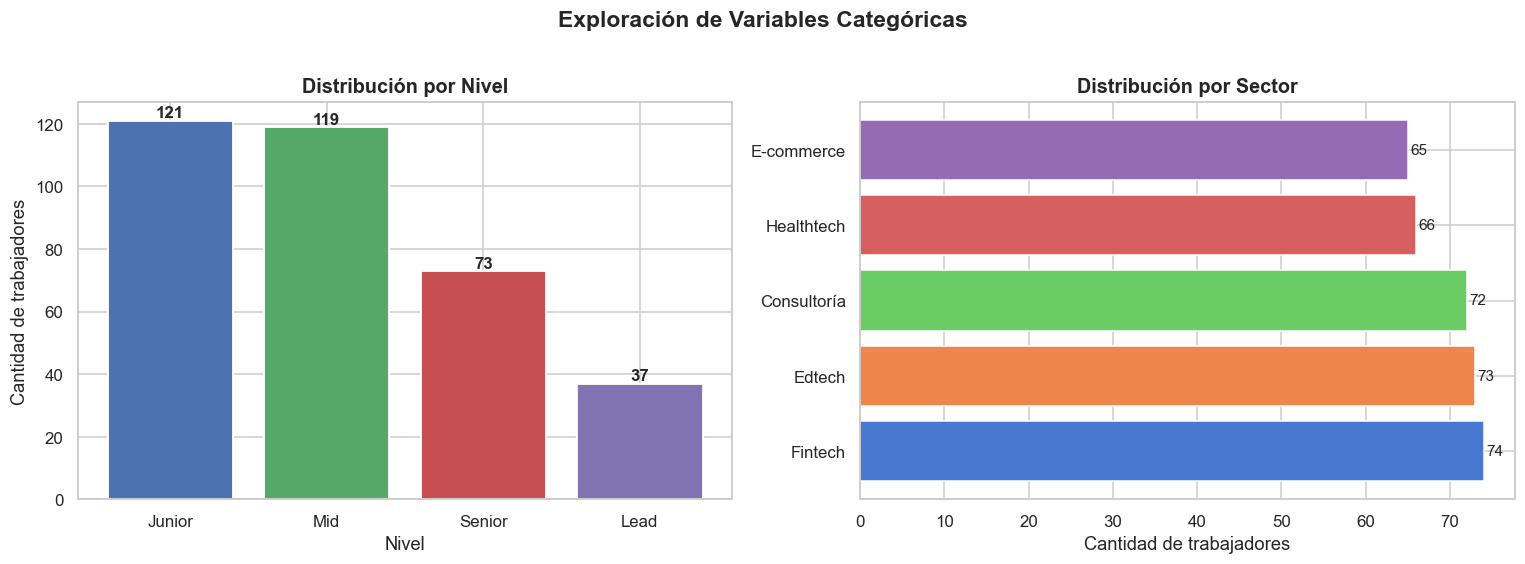

In [12]:
# 📊 Visualización: distribución de trabajadores por nivel y sector

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# fig: el lienzo completo (la "hoja de papel")
# axes: lista de los 2 ejes (subgráficas) que crearemos en esa hoja
# figsize=(14, 5): ancho=14 pulgadas, alto=5 pulgadas

# --- Gráfica 1: nivel de los trabajadores ---
orden_nivel = ['Junior', 'Mid', 'Senior', 'Lead']  # Definimos el orden lógico
conteo_nivel = df['nivel'].value_counts().reindex(orden_nivel)  # Reordenamos según nuestra lista

axes[0].bar(
    conteo_nivel.index,   # Eje X: las categorías (Junior, Mid, Senior, Lead)
    conteo_nivel.values,  # Eje Y: la cantidad de cada categoría
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],  # Un color por barra
    edgecolor='white',    # Borde blanco entre barras para mejor contraste
    linewidth=1.2
)
axes[0].set_title('Distribución por Nivel', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nivel')   # Etiqueta del eje X
axes[0].set_ylabel('Cantidad de trabajadores')  # Etiqueta del eje Y

# Añadimos el número encima de cada barra
for i, v in enumerate(conteo_nivel.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=11, fontweight='bold')

# --- Gráfica 2: distribución por sector ---
conteo_sector = df['sector'].value_counts()

axes[1].barh(
    conteo_sector.index,   # Eje Y: los sectores (barh = barras horizontales)
    conteo_sector.values,  # Eje X: la cantidad
    color=sns.color_palette('muted', len(conteo_sector))  # Paleta automática de seaborn
)
axes[1].set_title('Distribución por Sector', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cantidad de trabajadores')

# Añadimos etiquetas al final de cada barra horizontal
for i, v in enumerate(conteo_sector.values):
    axes[1].text(v + 0.3, i, str(v), va='center', fontsize=10)

plt.suptitle('Exploración de Variables Categóricas', fontsize=15, fontweight='bold', y=1.02)
# suptitle: título general que abarca toda la figura (super-título)

plt.tight_layout()  # Ajusta automáticamente el espaciado para que nada se solape
plt.show()

---
## 🕳️ Sección 2 — Detección y Tratamiento de Valores Nulos

### ¿Qué es un valor nulo?

Un valor nulo (`NaN` — *Not a Number*) representa **ausencia de información** en una celda. Puede ocurrir por:
- Errores al capturar datos
- Campos opcionales que no fueron llenados
- Problemas en la integración de fuentes de datos

### ¿Por qué importa?

La mayoría de los algoritmos de machine learning **no pueden operar con nulos** — lanzarán un error o producirán resultados incorrectos. Por eso, detectar y tratar nulos es uno de los primeros pasos del preprocesamiento.

### Métodos de detección

| Método | Qué hace |
|--------|----------|
| `isnull()` | Devuelve True/False por celda indicando si es nulo |
| `isnull().sum()` | Cuenta el total de nulos por columna |
| `isnull().mean() * 100` | Calcula el **porcentaje** de nulos por columna |

In [13]:
# Conteo de nulos por columna
nulos = df.isnull().sum()

# Porcentaje de nulos sobre el total de filas
porcentaje_nulos = (df.isnull().mean() * 100).round(2)

# Construimos una tabla resumen más informativa
resumen_nulos = pd.DataFrame({
    'Nulos':       nulos,
    'Porcentaje':  porcentaje_nulos,
    'Dtype':       df.dtypes
})

# Solo mostramos filas donde haya al menos 1 nulo
print('Columnas con valores nulos:')
print(resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False))

Columnas con valores nulos:
                      Nulos  Porcentaje    Dtype
salario_cop              35       10.00  float64
nivel_estres             28        8.00  float64
satisfaccion_laboral     22        6.29  float64
ciudad                   15        4.29      str


In [ ]:
# 📊 Visualización 1: mapa de calor de nulos
# Un heatmap de nulos nos permite ver de un vistazo dónde están concentrados los valores faltantes

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Gráfica 1: Heatmap de presencia/ausencia ---
# isnull() devuelve True (=1) donde hay nulo y False (=0) donde hay dato
# Rotamos solo las columnas que tienen nulos para mayor claridad
cols_con_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0].index

sns.heatmap(
    df[cols_con_nulos].isnull(),  # Matriz booleana: True=nulo, False=dato presente
    ax=axes[0],                   # En cuál eje dibujar
    cbar=False,                   # No mostramos barra de color (solo hay 2 valores posibles)
    cmap='YlOrRd',                # Paleta: amarillo=dato presente, rojo=nulo
    yticklabels=False             # Ocultamos etiquetas del eje Y (una por fila sería demasiado)
)
axes[0].set_title('Mapa de calor de valores nulos\n(rojo = nulo, amarillo = dato presente)', fontsize=12)
axes[0].set_xlabel('Columnas')
axes[0].set_ylabel('Filas del dataset')

# --- Gráfica 2: Barras de porcentaje de nulos ---
datos_grafica = resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Nulos')

bars = axes[1].barh(
    datos_grafica.index,          # Nombre de las columnas en eje Y
    datos_grafica['Porcentaje'],  # Porcentaje de nulos en eje X
    color=['#e07b54' if p > 7 else '#5b9bd5' for p in datos_grafica['Porcentaje']],
    # Coloreamos de naranja las columnas con más del 7% de nulos como alerta visual
    edgecolor='white'
)

# Línea de referencia al 10% — umbral común para decidir si eliminar una columna
axes[1].axvline(x=10, color='red', linestyle='--', linewidth=1.5, label='Umbral 10%')
axes[1].set_title('Porcentaje de nulos por columna', fontsize=12)
axes[1].set_xlabel('Porcentaje de valores nulos (%)')
axes[1].legend()

# Etiquetas con el porcentaje exacto al final de cada barra
for bar, pct in zip(bars, datos_grafica['Porcentaje']):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{pct}%', va='center', fontsize=10)

plt.suptitle('Diagnóstico de Valores Nulos', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.1 — Estrategias de Imputación: ¿cuándo usar cada una?

**Imputar** significa reemplazar un valor nulo por un valor calculado. La elección depende de la distribución de los datos:

| Estrategia | Cuándo usarla | Ventaja | Desventaja |
|-----------|---------------|---------|------------|
| **Media** | Distribución simétrica, sin outliers | Simple, preserva la media | Sensible a valores extremos |
| **Mediana** | Distribución asimétrica o con outliers | Robusta ante valores extremos | Puede subestimar la variabilidad |
| **Moda** | Variables categóricas o discretas con pocos valores | La única opción para texto | Puede crear desbalance si la moda es muy frecuente |
| **Valor constante** | Cuando el nulo tiene un significado propio | Conserva la información semántica | Requiere conocimiento del dominio |

💡 **Regla práctica**: si la columna tiene outliers significativos → usa mediana. Si la distribución es normal → la media es aceptable.

In [ ]:
# Antes de imputar, analizamos la distribución de las columnas con nulos
# para justificar técnicamente nuestra elección

cols_numericas_con_nulos = ['salario_cop', 'nivel_estres', 'satisfaccion_laboral']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(cols_numericas_con_nulos):
    datos = df[col].dropna()  # Eliminamos nulos solo para graficar la distribución existente
    
    # histplot dibuja un histograma: divide el rango en 'bins' intervalos y cuenta cuántos valores caen en cada uno
    sns.histplot(
        datos,
        ax=axes[i],
        kde=True,        # kde=True superpone una curva de densidad suavizada (Kernel Density Estimation)
        bins=20,         # Número de intervalos del histograma
        color='steelblue',
        edgecolor='white'
    )
    
    # Calculamos media y mediana para visualizarlas
    media = datos.mean()
    mediana = datos.median()
    
    # axvline dibuja una línea vertical en el valor indicado
    axes[i].axvline(media,   color='red',    linestyle='--', linewidth=1.8, label=f'Media: {media:,.1f}')
    axes[i].axvline(mediana, color='green',  linestyle='-',  linewidth=1.8, label=f'Mediana: {mediana:,.1f}')
    
    axes[i].set_title(f'Distribución: {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribuciones antes de imputar — ¿Media o Mediana?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print('📌 Interpretación:')
print('Si media ≈ mediana → distribución simétrica → media es válida')
print('Si media > mediana → cola derecha (datos altos extremos) → usar mediana')
print('Si media < mediana → cola izquierda (datos bajos extremos) → usar mediana')

In [ ]:
# ── Imputación 1: salario_cop ──────────────────────────────────────────
# El salario suele tener outliers altos (ejecutivos, leads con salarios muy superiores)
# Por eso elegimos MEDIANA: es más robusta ante esos valores extremos

mediana_salario = df['salario_cop'].median()
print(f'Mediana de salario: ${mediana_salario:,.0f} COP')
print(f'Media de salario:   ${df["salario_cop"].mean():,.0f} COP  ← observe la diferencia')

# .fillna(valor) reemplaza todos los NaN de la columna con el valor indicado
df['salario_cop'] = df['salario_cop'].fillna(mediana_salario)
print(f'\nNulos restantes en salario_cop: {df["salario_cop"].isnull().sum()}')

In [ ]:
# ── Imputación 2: nivel_estres ─────────────────────────────────────────
# Revisamos si la distribución es aproximadamente simétrica
media_estres   = df['nivel_estres'].mean()
mediana_estres = df['nivel_estres'].median()
print(f'Media nivel_estres:   {media_estres:.2f}')
print(f'Mediana nivel_estres: {mediana_estres:.2f}')
print()

# Como media y mediana son muy cercanas, la distribución es aproximadamente simétrica
# En este caso AMBAS opciones son válidas. Usaremos la MEDIA como ejercicio diferente
df['nivel_estres'] = df['nivel_estres'].fillna(media_estres)
print(f'Nulos restantes en nivel_estres: {df["nivel_estres"].isnull().sum()}')

In [ ]:
# ── Imputación 3: satisfaccion_laboral ────────────────────────────────
# Es una escala ordinal del 1 al 10 — la mediana preserva mejor el sentido de la escala
mediana_satisfaccion = df['satisfaccion_laboral'].median()
print(f'Mediana satisfaccion_laboral: {mediana_satisfaccion}')

df['satisfaccion_laboral'] = df['satisfaccion_laboral'].fillna(mediana_satisfaccion)
print(f'Nulos restantes en satisfaccion_laboral: {df["satisfaccion_laboral"].isnull().sum()}')

In [ ]:
# ── Imputación 4: ciudad (variable categórica) ────────────────────────
# Para variables de texto, usamos la MODA (el valor más frecuente)
# .mode() devuelve una Series — tomamos el primer elemento [0]
moda_ciudad = df['ciudad'].mode()[0]
print(f'Ciudad más frecuente (moda): {moda_ciudad}')
print(f'Distribución actual de ciudades:\n{df["ciudad"].value_counts()}')

df['ciudad'] = df['ciudad'].fillna(moda_ciudad)
print(f'\nNulos restantes en ciudad: {df["ciudad"].isnull().sum()}')

In [ ]:
# Verificación final: ninguna columna debe tener nulos
print('Estado final de nulos:')
print(df.isnull().sum())
print()
print(f'Total de nulos en todo el dataset: {df.isnull().sum().sum()}')

---
## 📦 Sección 3 — Detección de Outliers con el Método IQR

### ¿Qué es un outlier?

Un **outlier** (valor atípico) es un dato que se aleja significativamente del resto del conjunto. Puede ser:
- Un **error de captura** (ej: alguien ingresó 400 horas semanales)
- Un **caso genuinamente extremo** (ej: un directivo con salario muy alto)

### ¿Qué es el IQR?

El **Rango Intercuartílico** (IQR) mide la dispersión del 50% central de los datos:

$$IQR = Q3 - Q1$$

Con el IQR definimos **límites** fuera de los cuales un dato se considera atípico:

$$\text{Límite inferior} = Q1 - 1.5 \times IQR$$
$$\text{Límite superior} = Q3 + 1.5 \times IQR$$

El factor **1.5** es una convención estadística propuesta por John Tukey (1977). Un valor de 3 se usa para outliers "extremos".

### ¿Por qué IQR y no simplemente la media?

Porque el IQR es **resistente** — los outliers no afectan a Q1 ni a Q3 (solo afectan a la media y la desviación estándar). Es decir, usamos el IQR precisamente porque los outliers no lo distorsionan.

In [ ]:
# Creamos una función reutilizable que aplique IQR a cualquier columna
def detectar_outliers_iqr(dataframe, columna):
    """
    Detecta outliers usando el método IQR.
    Retorna un diccionario con los resultados del análisis.
    """
    Q1  = dataframe[columna].quantile(0.25)  # Cuartil 1: el 25% de los datos está por debajo
    Q3  = dataframe[columna].quantile(0.75)  # Cuartil 3: el 75% de los datos está por debajo
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Máscara booleana: True donde el dato está FUERA de los límites
    mascara_outliers = (
        (dataframe[columna] < limite_inferior) |
        (dataframe[columna] > limite_superior)
    )
    
    outliers_df = dataframe[mascara_outliers]
    
    return {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'n_outliers': len(outliers_df),
        'outliers': outliers_df
    }

# Aplicamos la función a múltiples columnas numéricas
columnas_a_revisar = ['horas_semana', 'salario_cop', 'dias_ausencia_anio', 'nivel_estres']

print(f'{'Columna':<25} {'Q1':>12} {'Q3':>12} {'IQR':>10} {'Lím. Inf':>12} {'Lím. Sup':>12} {'Outliers':>10}')
print('-' * 97)

resultados_iqr = {}
for col in columnas_a_revisar:
    r = detectar_outliers_iqr(df, col)
    resultados_iqr[col] = r
    print(f'{col:<25} {r["Q1"]:>12.2f} {r["Q3"]:>12.2f} {r["IQR"]:>10.2f} '
          f'{r["limite_inferior"]:>12.2f} {r["limite_superior"]:>12.2f} {r["n_outliers"]:>10}')

In [ ]:
# Veamos el detalle de los outliers detectados
for col in columnas_a_revisar:
    r = resultados_iqr[col]
    if r['n_outliers'] > 0:
        print(f'\n🔴 Outliers en [{col}]:')
        print(r['outliers'][['id_trabajador', 'cargo', 'nivel', col]].to_string(index=False))

In [ ]:
# 📊 Visualización: boxplots para identificar outliers visualmente
# El boxplot es la representación gráfica perfecta del IQR

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # Convertimos la matriz 2x2 en una lista de 4 ejes para iterar fácilmente

for i, col in enumerate(columnas_a_revisar):
    r = resultados_iqr[col]
    
    # boxplot dibuja la caja con bigotes:
    # - La caja va de Q1 a Q3 (IQR)
    # - La línea interior es la mediana (Q2)
    # - Los bigotes van hasta los límites IQR
    # - Los puntos fuera de los bigotes son outliers
    axes[i].boxplot(
        df[col].dropna(),
        vert=True,                           # Orientación vertical
        patch_artist=True,                   # Rellena la caja con color
        boxprops=dict(facecolor='#5b9bd5', color='navy'),  # Color de la caja
        medianprops=dict(color='red', linewidth=2.5),       # Línea de la mediana
        flierprops=dict(marker='o', color='orange',         # Estilo de los outliers
                        markersize=8, markerfacecolor='orange'),
        whiskerprops=dict(color='navy', linewidth=1.5),     # Bigotes
        capprops=dict(color='navy', linewidth=2)            # Tapas de los bigotes
    )
    
    # Líneas de referencia para los límites calculados
    axes[i].axhline(r['limite_inferior'], color='red',   linestyle='--', alpha=0.7,
                    label=f'Lím. inf: {r["limite_inferior"]:.1f}')
    axes[i].axhline(r['limite_superior'], color='green', linestyle='--', alpha=0.7,
                    label=f'Lím. sup: {r["limite_superior"]:.1f}')
    
    axes[i].set_title(f'{col}\nOutliers detectados: {r["n_outliers"]}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].legend(fontsize=9)

plt.suptitle('Detección de Outliers — Método IQR\n(puntos naranjas = posibles outliers)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📐 Sección 4 — Z-Score: Estandarización y Detección de Outliers

### ¿Qué es el Z-Score?

El **Z-Score** (también llamado puntuación estándar) mide cuántas **desviaciones estándar** está un valor alejado de la media:

$$Z = \frac{x - \mu}{\sigma}$$

Donde:
- $x$ = el valor del dato
- $\mu$ = media de la columna
- $\sigma$ = desviación estándar de la columna

### ¿Para qué sirve?

**1. Estandarización**: transforma los datos para que tengan media = 0 y desviación estándar = 1. Esto permite **comparar variables con escalas diferentes** (ej: salario en millones vs. horas semanales).

**2. Detección de outliers**: por convención, se considera outlier cualquier valor con $|Z| > 3$ (está a más de 3 desviaciones estándar de la media).

### IQR vs Z-Score: ¿cuándo usar cada uno?

| Característica | IQR | Z-Score |
|---------------|-----|--------|
| Sensible a outliers | ❌ No (robusto) | ✅ Sí (los outliers afectan la media y std) |
| Supone distribución normal | ❌ No | ✅ Sí |
| Mejor para | Datos con distribución asimétrica | Datos con distribución aproximadamente normal |
| Umbral estándar | 1.5 × IQR | |Z| > 3 |

In [ ]:
# Calculamos el Z-Score de forma manual para entender la fórmula
# Trabajamos sobre salario_cop y horas_semana

columnas_zscore = ['salario_cop', 'horas_semana', 'nivel_estres', 'satisfaccion_laboral']

for col in columnas_zscore:
    media = df[col].mean()   # μ
    std   = df[col].std()    # σ
    
    # Aplicamos la fórmula elemento a elemento con pandas (vectorizado)
    nombre_col_z = f'z_{col.replace("_cop", "")}'
    df[nombre_col_z] = (df[col] - media) / std
    
    outliers_z = df[df[nombre_col_z].abs() > 3]
    print(f'{col}: media={media:,.1f}, std={std:,.1f} → outliers Z-score: {len(outliers_z)}')

In [ ]:
# Veamos los valores estandarizados — el Z-Score de salario
print('Comparación: salario original vs Z-Score de salario')
print(df[['id_trabajador', 'cargo', 'nivel', 'salario_cop', 'z_salario']]
      .sort_values('z_salario', ascending=False)
      .head(10)
      .to_string(index=False))

print('\n--- Estadísticas del Z-Score (debe ser ≈ media=0, std=1) ---')
print(df['z_salario'].describe().round(4))

In [ ]:
# 📊 Visualización: distribución del Z-Score con zonas coloreadas

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Gráfica 1: Distribución del Z-Score de salario ---
z_vals = df['z_salario']

# histplot: histograma con curva de densidad superpuesta
sns.histplot(
    z_vals, ax=axes[0],
    bins=30, kde=True,
    color='steelblue', edgecolor='white'
)

# Zonas de alerta: sombreamos el área fuera de ±3 desviaciones estándar
axes[0].axvspan(-10, -3, alpha=0.15, color='red', label='Zona outlier (Z < -3)')
axes[0].axvspan(3, 20,  alpha=0.15, color='red', label='Zona outlier (Z > +3)')
# axvspan: sombrea una región vertical entre x1 y x2 (alpha controla la transparencia)

# Líneas en ±3
axes[0].axvline(-3, color='red', linestyle='--', linewidth=1.5)
axes[0].axvline( 3, color='red', linestyle='--', linewidth=1.5, label='Umbral ±3')
axes[0].axvline( 0, color='black', linestyle='-', linewidth=1, alpha=0.5, label='Media = 0')

axes[0].set_title('Distribución Z-Score: Salario COP', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Z-Score (desviaciones estándar desde la media)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)

# --- Gráfica 2: Scatter — salario original vs Z-Score ---
# Coloreamos los puntos según si son outlier o no
es_outlier = df['z_salario'].abs() > 3

axes[1].scatter(
    df.loc[~es_outlier, 'id_trabajador'],  # ~ invierte la máscara (los NO outliers)
    df.loc[~es_outlier, 'salario_cop'],
    color='steelblue', alpha=0.5, s=20, label='Normal'
)
axes[1].scatter(
    df.loc[es_outlier, 'id_trabajador'],
    df.loc[es_outlier, 'salario_cop'],
    color='red', s=80, zorder=5, label='Outlier (|Z| > 3)',  # zorder: dibuja encima de los otros puntos
    edgecolors='darkred', linewidth=1.5
)

axes[1].set_title('Salario COP por Trabajador\n(outliers en rojo)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ID Trabajador')
axes[1].set_ylabel('Salario COP')
axes[1].legend()

plt.suptitle('Análisis de Outliers con Z-Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔧 Sección 5 — Transformaciones Adicionales

Una vez limpios los datos, podemos hacer transformaciones que los enriquecen para análisis futuros. Aquí trabajaremos la columna `fecha_ingreso`, que aún está como texto (`str`) y necesita convertirse a un tipo fecha real.

### ¿Por qué convertir fechas?

Un texto `'01/01/2018'` no se puede operar matemáticamente. Una vez convertido a `datetime`, podemos:
- Extraer el año, mes o día fácilmente
- Calcular diferencias entre fechas (ej: antigüedad en la empresa)
- Filtrar por rangos temporales

In [ ]:
# Convertimos fecha_ingreso de string a datetime
# pd.to_datetime() infiere o acepta el formato explícito de la fecha
df['fecha_ingreso'] = pd.to_datetime(df['fecha_ingreso'], format='%d/%m/%Y')
print('Tipo de dato después de la conversión:', df['fecha_ingreso'].dtype)
print(df['fecha_ingreso'].head())

In [ ]:
# Ahora podemos extraer componentes de la fecha con el acceso .dt
# .dt es un accessor especial de pandas para columnas de tipo datetime
df['anio_ingreso'] = df['fecha_ingreso'].dt.year   # Extrae el año como entero
df['mes_ingreso']  = df['fecha_ingreso'].dt.month  # Extrae el mes (1-12)

# Calculamos la antigüedad: diferencia entre hoy y la fecha de ingreso, en años
hoy = pd.Timestamp.today()
df['antiguedad_anios'] = ((hoy - df['fecha_ingreso']).dt.days / 365.25).round(1)

print('Nuevas columnas de fecha:')
print(df[['id_trabajador', 'fecha_ingreso', 'anio_ingreso', 'mes_ingreso', 'antiguedad_anios']].head(8))

In [ ]:
# 📊 Visualización: ingresos por año y satisfacción por nivel de antigüedad

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Gráfica 1: cuántos empleados ingresaron por año ---
ingresos_por_anio = df['anio_ingreso'].value_counts().sort_index()

axes[0].bar(
    ingresos_por_anio.index.astype(str),  # Eje X: años (como strings para etiquetas limpias)
    ingresos_por_anio.values,
    color=sns.color_palette('Blues_d', len(ingresos_por_anio)),
    edgecolor='white'
)
axes[0].set_title('Ingresos de Empleados por Año', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Año de ingreso')
axes[0].set_ylabel('Número de empleados')
for i, v in enumerate(ingresos_por_anio.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=10)

# --- Gráfica 2: relación antigüedad vs satisfacción laboral ---
# scatterplot dibuja un punto por cada fila, relacionando dos variables
sns.scatterplot(
    data=df,
    x='antiguedad_anios',       # Variable en eje X
    y='satisfaccion_laboral',   # Variable en eje Y
    hue='nivel',                # Colorea según el nivel del trabajador
    palette='Set2',             # Paleta de colores para las categorías
    alpha=0.7,                  # Transparencia para ver puntos superpuestos
    s=60,                       # Tamaño de cada punto
    ax=axes[1]
)
axes[1].set_title('Antigüedad vs Satisfacción Laboral\ncoloreado por nivel', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Antigüedad (años)')
axes[1].set_ylabel('Satisfacción laboral (1-10)')

plt.suptitle('Análisis Temporal: Fecha de Ingreso', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🗺️ Sección 6 — Resumen Final y Estado del Dataset

Siempre es buena práctica documentar qué transformaciones realizamos antes de guardar el dataset limpio.

In [ ]:
# Resumen del proceso realizado
print('=' * 60)
print('   RESUMEN DEL PREPROCESAMIENTO')
print('=' * 60)
print(f'\n📊 Registros totales: {len(df)}')
print(f'📋 Columnas finales:  {len(df.columns)}')
print(f'🕳️ Nulos restantes:   {df.isnull().sum().sum()}')

print('\n✅ Imputaciones realizadas:')
print('   • salario_cop        → mediana (distribución asimétrica)')
print('   • nivel_estres       → media   (distribución simétrica)')
print('   • satisfaccion_laboral → mediana (escala ordinal)')
print('   • ciudad             → moda    (variable categórica)')

print('\n📐 Nuevas columnas creadas:')
nuevas = ['z_salario', 'z_horas_semana', 'z_nivel_estres',
          'z_satisfaccion_laboral', 'anio_ingreso', 'mes_ingreso', 'antiguedad_anios']
for c in nuevas:
    if c in df.columns:
        print(f'   • {c}')

print('\n📦 Outliers detectados por IQR:')
for col, r in resultados_iqr.items():
    print(f'   • {col}: {r["n_outliers"]} outlier(s)')

In [ ]:
# 📊 Visualización final: mapa de correlación entre variables numéricas
# Una correlación mide qué tan relacionadas están dos variables (de -1 a +1)

# Seleccionamos solo las columnas originales (sin los Z-scores que son derivadas)
cols_originales = ['edad', 'anios_experiencia', 'horas_semana', 'salario_cop',
                   'nivel_estres', 'dias_ausencia_anio', 'satisfaccion_laboral', 'antiguedad_anios']

# .corr() calcula la correlación de Pearson entre todos los pares de columnas numéricas
matriz_correlacion = df[cols_originales].corr()

fig, ax = plt.subplots(figsize=(11, 8))

# heatmap con la matriz de correlaciones
sns.heatmap(
    matriz_correlacion,
    annot=True,        # annot=True: muestra el valor de correlación en cada celda
    fmt='.2f',         # Formato: 2 decimales
    cmap='RdYlGn',     # Paleta: rojo=correlación negativa, verde=correlación positiva
    vmin=-1, vmax=1,   # Rango fijo de la escala de colores
    center=0,          # El color neutro (amarillo) en correlación = 0
    square=True,       # Las celdas son cuadradas
    linewidths=0.5,    # Grosor de las líneas entre celdas
    ax=ax
)
ax.set_title('Mapa de Correlaciones entre Variables Numéricas\n(1 = correlación positiva perfecta, -1 = inversa perfecta)',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print()
print('💡 Pistas para interpretar:')
print('   • Verde intenso (≈ +1): cuando una sube, la otra también sube')
print('   • Rojo intenso  (≈ -1): cuando una sube, la otra baja')
print('   • Amarillo      (≈  0): no hay relación lineal aparente')

---
## 🧪 Ejercicios de Práctica

Intenta resolver estos ejercicios con lo que aprendiste hoy:

**Ejercicio 1 — Exploración**  
¿Cuál es el salario promedio por `nivel`? ¿Y la mediana? ¿Qué diferencia notas entre ambos?

**Ejercicio 2 — Nulos**  
Simula un nuevo nulo en `horas_semana` para los trabajadores del sector `Edtech`. Luego imputa usando la mediana **solo de ese sector**. (*Pista: usa `.loc[]` y `.groupby()`*)

**Ejercicio 3 — Outliers IQR**  
Aplica el método IQR a `dias_ausencia_anio` con un factor de **3.0** en lugar de 1.5. ¿Cambia la cantidad de outliers detectados? ¿Por qué?

**Ejercicio 4 — Z-Score**  
Calcula el Z-Score de `anios_experiencia`. ¿Qué trabajadores tienen un Z-Score mayor a 2? ¿Cuál es su cargo y nivel?

**Ejercicio 5 — Visualización**  
Crea un boxplot que compare `salario_cop` entre los diferentes `niveles` (Junior, Mid, Senior, Lead) en una sola figura. (*Pista: usa `seaborn.boxplot` con `x='nivel'` e `y='salario_cop'`*)

In [ ]:
# Espacio para el Ejercicio 1
# Tu código aquí:

In [ ]:
# Espacio para el Ejercicio 2
# Tu código aquí:

In [ ]:
# Espacio para el Ejercicio 3
# Tu código aquí:

In [ ]:
# Espacio para el Ejercicio 4
# Tu código aquí:

In [ ]:
# Espacio para el Ejercicio 5
# Tu código aquí: